# Q7 — Difficulty Breaking Into the Field by Education and Gender

**Question:** How does reported difficulty breaking into the field vary by education level and gender?

## Setup

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
sns.set_theme(style="whitegrid", palette="mako")
plt.rcParams["figure.dpi"] = 110

OUT = Path("charts")
OUT.mkdir(exist_ok=True)

# Load and clean - same cleaning decision made in the SQL phase:
# blank education values become the literal string 'None'
df = pd.read_csv("DataProfessionalSurvey_Clean.csv")
df["education"] = df["education"].fillna("None")
df["country"] = df["country"].str.strip()
df["role_name"] = df["role_name"].str.strip()

print(f"{len(df)} respondents loaded.")
df.head()

630 respondents loaded.


,respondent_id,date_taken,time_taken,time_spent,role_name,switched_careers,salary_band,salary_midpoint,industry,fav_language,...,satisfaction_mobility,satisfaction_learning,satisfaction_composite,difficulty_breaking_in,top_job_priority,gender,age,country,education,ethnicity
0,62a33b3db4da29969c62df3d,6/10/2022,8:38,0:00:44,Data Analyst,Yes,106-125,115500,Healthcare,Python,...,5.00,7.00,7.00,Very Difficult,Remote Work,Male,26,United States,None,White
1,62a33ba1bae91e4b8b82e35c,6/10/2022,8:40,0:01:30,Data Analyst,No,41-65,53000,Finance,R,...,1.00,3.00,2.33,Very Difficult,Remote Work,Male,36,Canada,None,Asian
2,62a33c2cbc6861bf3176bec1,6/10/2022,8:42,0:02:18,Data Engineer,No,0-40,20000,Other,Python,...,7.00,7.00,5.67,Easy,Good Work/Life Balance,Male,23,Rest of the world,None,Black
3,62a33c8624a26260273822f9,6/10/2022,8:43,0:02:10,Other,Yes,150 - 225,187500,Finance,R,...,7.00,10.00,8.33,Very Easy,Remote Work,Female,35,Canada,None,White
4,62a33c91f3072dd892621e03,6/10/2022,8:44,0:01:51,Data Analyst,Yes,41 - 65,53000,Healthcare,R,...,0.00,1.00,2.33,Difficult,Better Salary,Male,44,United States,None,Black


### By education (row % — each row sums to 100)

In [2]:
difficulty_by_education = (
    pd.crosstab(df["education"], df["difficulty_breaking_in"], normalize="index") * 100
).round(1)
difficulty_by_education

difficulty_breaking_in,Difficult,Easy,Neither easy nor difficult,Very Difficult,Very Easy
education,,,,,
Associates,18.80,25.00,43.80,6.20,6.20
Bachelors,24.00,21.90,43.20,6.70,4.30
High School,22.20,16.70,52.80,5.60,2.80
Masters,26.00,21.90,43.80,4.70,3.60
None,26.90,17.30,30.80,19.20,5.80
PhD,40.00,20.00,20.00,0.00,20.00


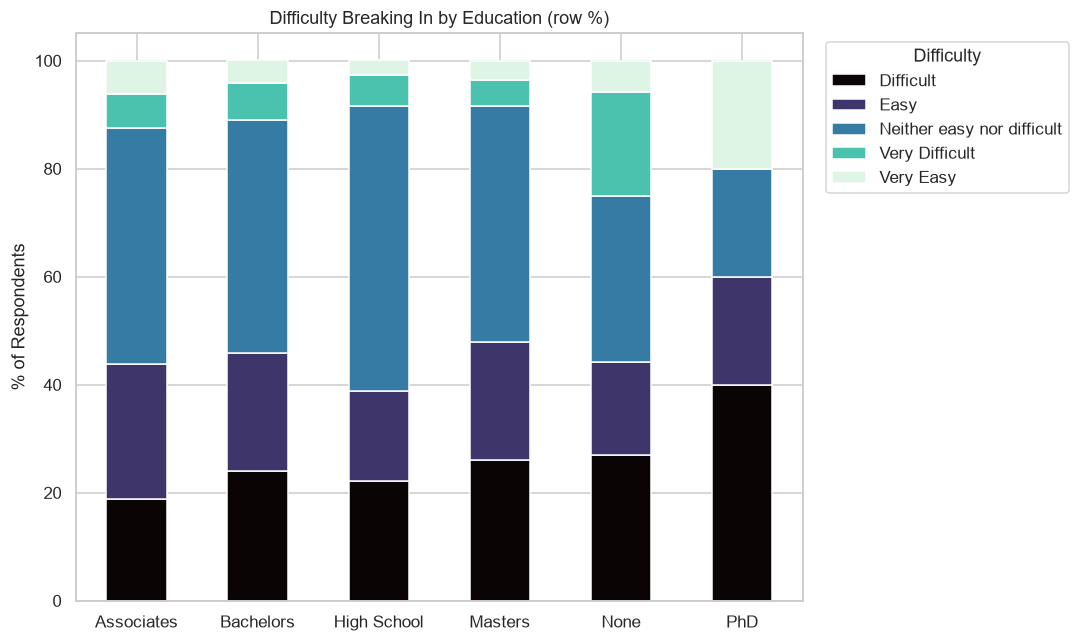

In [3]:
fig, ax = plt.subplots(figsize=(10, 6))
difficulty_by_education.plot(kind="bar", stacked=True, ax=ax, colormap="mako")
ax.set_title("Difficulty Breaking In by Education (row %)")
ax.set_ylabel("% of Respondents")
ax.set_xlabel("")
plt.xticks(rotation=0)
ax.legend(title="Difficulty", bbox_to_anchor=(1.02, 1), loc="upper left")
fig.tight_layout()
fig.savefig(OUT / "q7_difficulty_by_education_stacked.png", bbox_inches="tight")
plt.show()

### By gender (row %)

In [4]:
difficulty_by_gender = (
    pd.crosstab(df["gender"], df["difficulty_breaking_in"], normalize="index") * 100
).round(1)
difficulty_by_gender

difficulty_breaking_in,Difficult,Easy,Neither easy nor difficult,Very Difficult,Very Easy
gender,,,,,
Female,22.80,20.40,45.10,6.80,4.90
Male,25.40,21.60,41.90,7.10,4.10


**Takeaway:** Respondents with no formal education listed report 'Very Difficult' at roughly 3x the rate of every other education group — the clearest gradient in the whole dataset. Gender shows only a small gap by comparison.

##By Country

In [5]:
difficulty_by_country = (
    pd.crosstab(df["country"], df["difficulty_breaking_in"], normalize="index") * 100
).round(1)
difficulty_by_country

difficulty_breaking_in,Difficult,Easy,Neither easy nor difficult,Very Difficult,Very Easy
country,,,,,
Canada,21.90,18.80,43.80,12.50,3.10
India,27.40,17.80,43.80,5.50,5.50
Rest of the world,21.00,20.10,50.00,7.60,1.30
United Kingdom,30.00,30.00,25.00,2.50,12.50
United States,26.80,22.20,38.70,6.90,5.40
